# Visualização de Dados - Sample Superstore

Este notebook transforma os dados da análise final em uma prévia das visualizações dos gráficos para apoiar decisões de negócio

In [42]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.ticker import FuncFormatter

In [67]:
sns.set_theme(
    style='whitegrid',
    context='notebook'
)

COR_PRINCIPAL = '#287271'
COR_DESTAQUE = '#E9C46A'
COR_NEGATIVA = '#C94C4C'
COR_REFERENCIA = '#333333'

In [43]:
def carregar_dados(caminho):
    dados=pd.read_csv(caminho,encoding='utf-8',parse_dates=['Order Date', 'Ship Date'])
    return dados

In [44]:
caminho='../dados/tratado/superstore_tratado.csv'
df=carregar_dados(caminho)

In [45]:
lucro_anual=(
    df.groupby('ano')['Profit']
    .sum()
    .reset_index()
)

### Gráfico de lucro anual

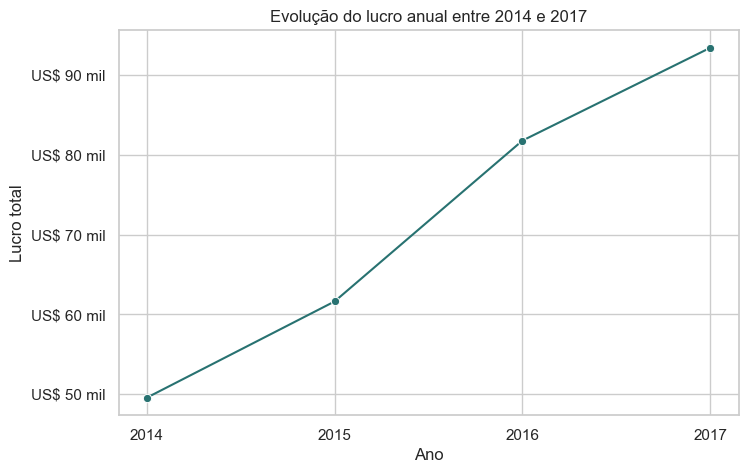

In [76]:
plt.figure(figsize=(8, 5))

ax=sns.lineplot(
    data=lucro_anual,
    x='ano',
    y='Profit',
    marker='o',
    color=COR_PRINCIPAL
)

ax.set_xticks(lucro_anual['ano'])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'{valor:.0f}')
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'US$ {valor / 1000:.0f} mil')
)

plt.title('Evolução do lucro anual entre 2014 e 2017')
plt.xlabel('Ano')
plt.ylabel('Lucro total')
plt.show()

### Lucro total por categoria

In [47]:
lucro_total_categoria=(
    df.groupby('Category')['Profit']
    .sum()
    .reset_index()
)

### Gráfico de lucro total por categoria

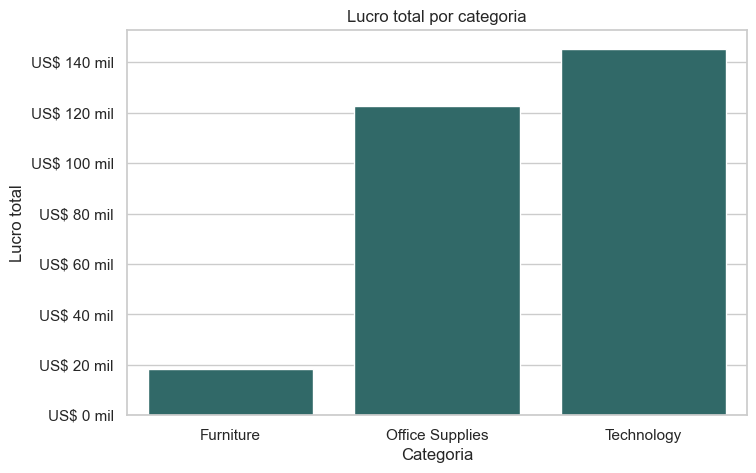

In [77]:
plt.figure(figsize=(8, 5))

ax=sns.barplot(
    data=lucro_total_categoria,
    x='Category',
    y='Profit',
    color=COR_PRINCIPAL
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'US$ {valor / 1000:.0f} mil')
)

plt.title('Lucro total por categoria')
plt.xlabel('Categoria')
plt.ylabel('Lucro total')
plt.show()



### Lucro das subcategorias de Furniture

In [49]:
furniture=df[df['Category']=='Furniture']
lucro_subcategoria_furniture=(
    furniture.groupby('Sub-Category')['Profit']
    .sum()
    .reset_index()
)

### Gráfico das subcategorias de Furniture

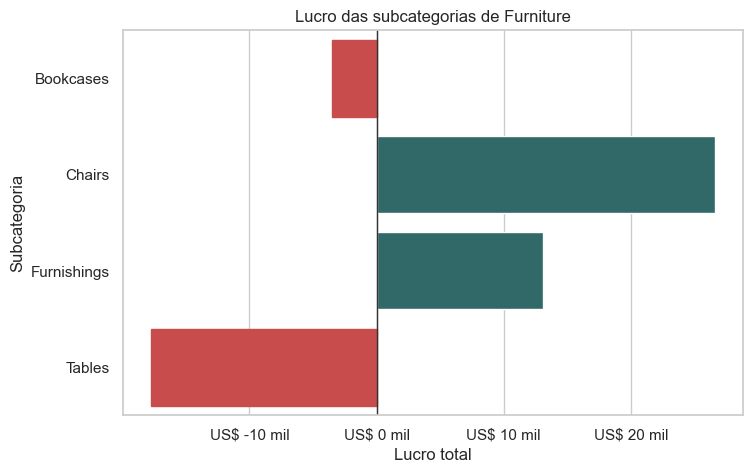

In [85]:
plt.figure(figsize=(8, 5))

ax=sns.barplot(
    data=lucro_subcategoria_furniture,
    x='Profit',
    y='Sub-Category',
    color=COR_PRINCIPAL
)

for barra, lucro in zip(
    ax.patches,
    lucro_subcategoria_furniture['Profit']
):
    if lucro < 0:
        barra.set_color(COR_NEGATIVA)

ax.axvline(0, color=COR_REFERENCIA, linewidth=1)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'US$ {valor / 1000:.0f} mil')
)

plt.title('Lucro das subcategorias de Furniture')
plt.ylabel('Subcategoria')
plt.xlabel('Lucro total')
plt.show()

### Lucro por faixa de desconto

In [51]:
lucro_faixa_desconto=(
    df.groupby('faixa_desconto')['Profit']
    .sum()
    .reset_index()
)

### Gráfico lucro por faixa de desconto

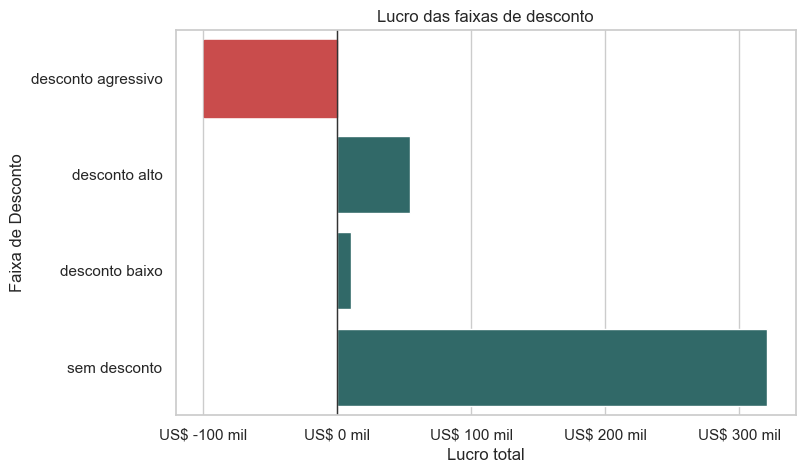

In [86]:
plt.figure(figsize=(8, 5))

ax=sns.barplot(
    data=lucro_faixa_desconto,
    x='Profit',
    y='faixa_desconto',
    color=COR_PRINCIPAL
)

for barra, lucro in zip(
    ax.patches,
    lucro_faixa_desconto['Profit']
):
    if lucro < 0:
        barra.set_color(COR_NEGATIVA)

ax.axvline(0, color=COR_REFERENCIA, linewidth=1)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'US$ {valor / 1000:.0f} mil')
)


plt.title('Lucro das faixas de desconto')
plt.ylabel('Faixa de Desconto')
plt.xlabel('Lucro total')
plt.show()

### Lucro total por região

In [53]:
lucro_total_regiao=(
    df.groupby('Region')['Profit']
    .sum()
    .reset_index()
)

### Gráfico lucro total por região

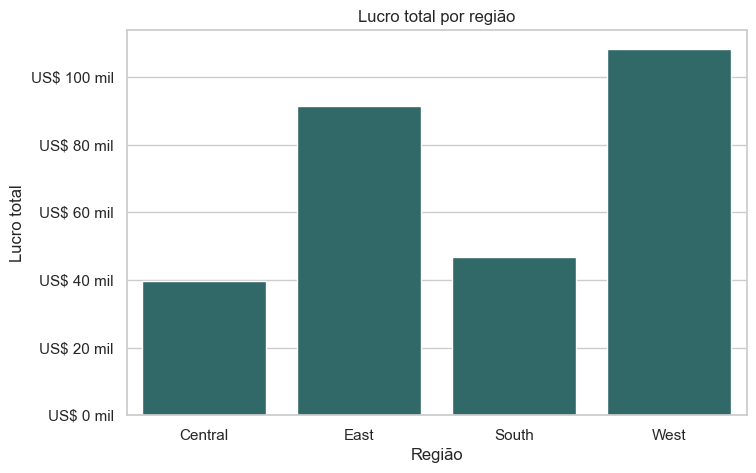

In [80]:
plt.figure(figsize=(8, 5))

ax=sns.barplot(
    data=lucro_total_regiao,
    x='Region',
    y='Profit',
    color=COR_PRINCIPAL
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'US$ {valor / 1000:.0f} mil')
)


plt.title('Lucro total por região')
plt.ylabel('Lucro total')
plt.xlabel('Região')
plt.show()

### Margem global por região

In [73]:
margem_regiao=df.groupby('Region').agg(
    faturamento_total=('Sales', 'sum'),
    lucro_total=('Profit', 'sum')
)

margem_regiao['margem_global']=(
    margem_regiao['lucro_total']/margem_regiao['faturamento_total']
)

margem_regiao=margem_regiao.reset_index()

### Gráfico da margem global por região

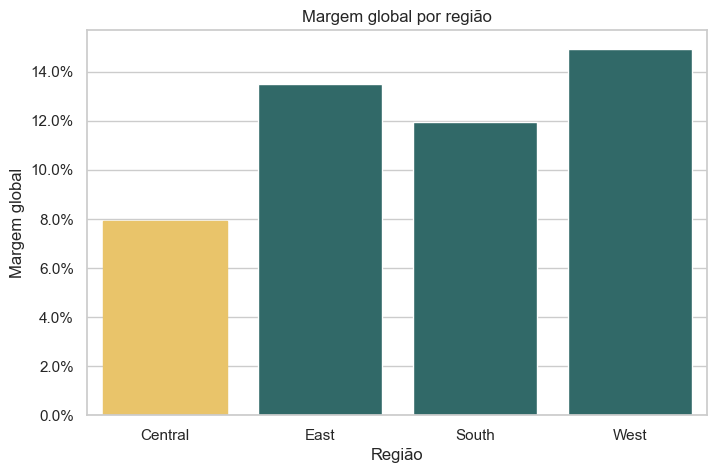

In [82]:
plt.figure(figsize=(8, 5))

ax=sns.barplot(
    data=margem_regiao,
    x='Region',
    y='margem_global',
    color=COR_PRINCIPAL
)

for barra, regiao in zip(
    ax.patches,
    margem_regiao['Region']
):
    if regiao == 'Central':
        barra.set_color(COR_DESTAQUE)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'{valor:.1%}')
)

plt.title('Margem global por região')
plt.xlabel('Região')
plt.ylabel('Margem global')
plt.show()

### Desempenho mensal

In [62]:
lucro_mensal=(
    df.groupby(['ano', 'mes'])['Profit']
    .sum()
    .reset_index()
)

lucro_mensal['data']=pd.to_datetime(
    dict(
        year=lucro_mensal['ano'],
        month=lucro_mensal['mes'],
        day=1
    )
)

### Gráfico do lucro mensal

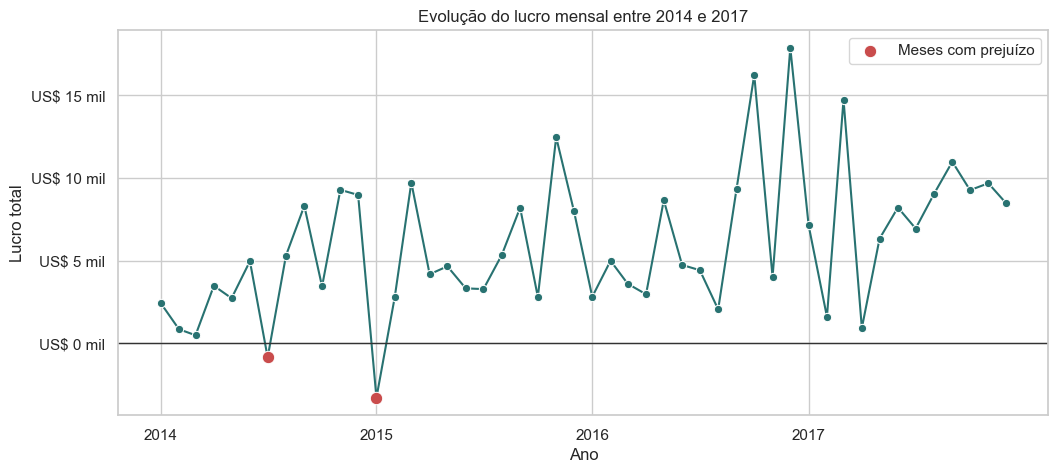

In [83]:
meses_prejuizo=lucro_mensal[lucro_mensal['Profit'] < 0]
anos=lucro_mensal.drop_duplicates('ano')

plt.figure(figsize=(12, 5))

ax=sns.lineplot(
    data=lucro_mensal,
    x='data',
    y='Profit',
    marker='o',
    color=COR_PRINCIPAL
)

sns.scatterplot(
    data=meses_prejuizo,
    x='data',
    y='Profit',
    color=COR_NEGATIVA,
    s=80,
    zorder=3,
    label='Meses com prejuízo',
    ax=ax
)

ax.axhline(0, color=COR_REFERENCIA, linewidth=1)
ax.set_xticks(anos['data'])
ax.set_xticklabels(anos['ano'])
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'US$ {valor / 1000:.0f} mil')
)

plt.title('Evolução do lucro mensal entre 2014 e 2017')
plt.xlabel('Ano')
plt.ylabel('Lucro total')
plt.show()

### Margem global por segmento

In [63]:
margem_segmento=df.groupby('Segment').agg(
    faturamento_total=('Sales', 'sum'),
    lucro_total=('Profit', 'sum')
).reset_index()

margem_segmento['margem_global']=(
    margem_segmento['lucro_total']/margem_segmento['faturamento_total']
)

### Gráfico da margem global por segmento

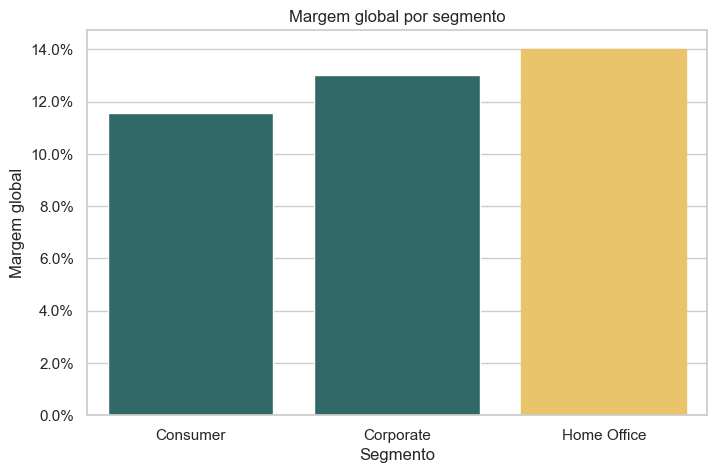

In [84]:
plt.figure(figsize=(8, 5))

ax=sns.barplot(
    data=margem_segmento,
    x='Segment',
    y='margem_global',
    color=COR_PRINCIPAL
)

for barra, segmento in zip(
    ax.patches,
    margem_segmento['Segment']
):
    if segmento == 'Home Office':
        barra.set_color(COR_DESTAQUE)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f'{valor:.1%}')
)

plt.title('Margem global por segmento')
plt.xlabel('Segmento')
plt.ylabel('Margem global')
plt.show()